In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('data/mpg.csv')
print(f"Total rows: {len(df)}")
print("\nMissing values:")
print(df.isna().sum())

Total rows: 398

Missing values:
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64


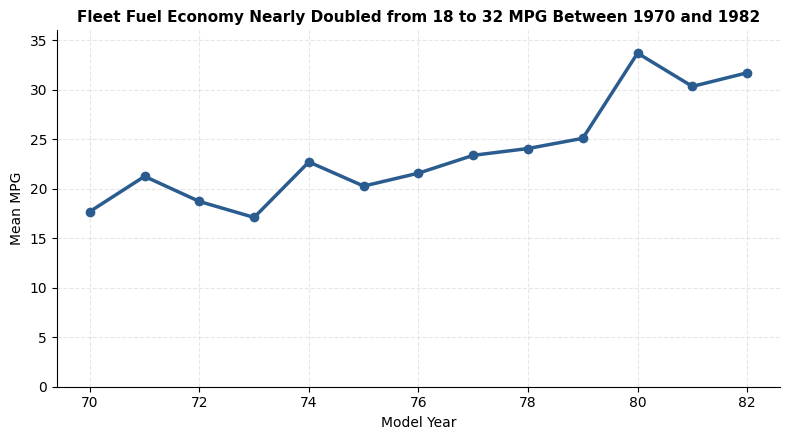

In [2]:
annual_mpg = df.groupby('model_year')['mpg'].mean()

plt.figure(figsize=(8, 4.5))
plt.plot(annual_mpg.index, annual_mpg.values, marker='o', lw=2.5, color='#2b5c8f')
plt.title("Fleet Fuel Economy Nearly Doubled from 18 to 32 MPG Between 1970 and 1982", fontsize=11, fontweight='bold')
plt.xlabel("Model Year")
plt.ylabel("Mean MPG")
plt.ylim(bottom=0, top=36)
plt.grid(True, linestyle='--', alpha=0.3)
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

### Justification Q1
A **line chart** is chosen because `model_year` is an ordered, continuous sequence where the objective is to display the long-term temporal trajectory and rate of change.

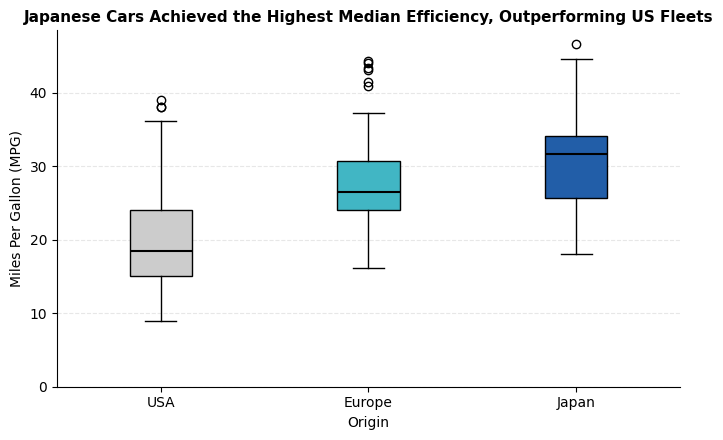

In [3]:
origins = ['usa', 'europe', 'japan']
data_by_origin = [df[df['origin'] == o]['mpg'] for o in origins]

plt.figure(figsize=(7, 4.5))
bplot = plt.boxplot(data_by_origin, tick_labels=['USA', 'Europe', 'Japan'], patch_artist=True, medianprops=dict(color='black', lw=1.5))
colors = ['#cccccc', '#41b6c4', '#225ea8']
for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)

plt.title("Japanese Cars Achieved the Highest Median Efficiency, Outperforming US Fleets", fontsize=11, fontweight='bold')
plt.xlabel("Origin")
plt.ylabel("Miles Per Gallon (MPG)")
plt.ylim(bottom=0)
plt.grid(True, axis='y', linestyle='--', alpha=0.3)
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

### Justification Q2
A **box plot** compares both the median performance and the spread/variance across 3 discrete categorical groups without collapsing the distribution into a single misleading average.

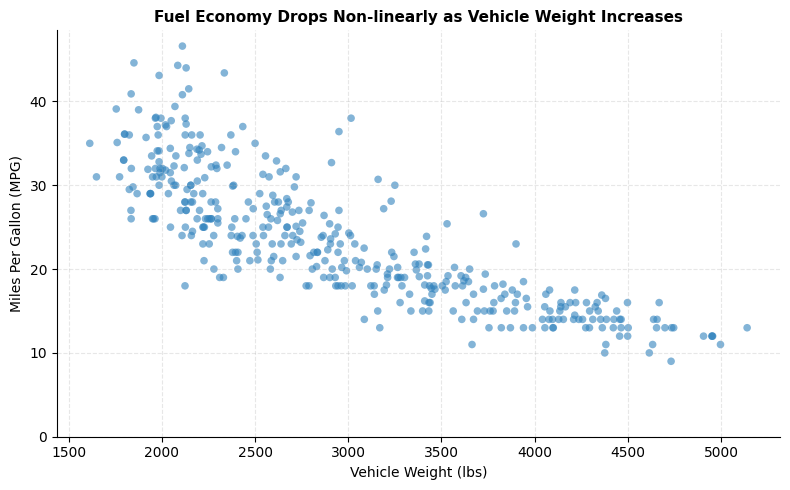

In [4]:
plt.figure(figsize=(8, 5))
plt.scatter(df['weight'], df['mpg'], color='#3182bd', alpha=0.6, s=30, edgecolors='none')
plt.title("Fuel Economy Drops Non-linearly as Vehicle Weight Increases", fontsize=11, fontweight='bold')
plt.xlabel("Vehicle Weight (lbs)")
plt.ylabel("Miles Per Gallon (MPG)")
plt.ylim(bottom=0)
plt.grid(True, linestyle='--', alpha=0.3)
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

### Justification Q3
A **scatter plot** is mandatory when examining the relationship and functional form between two continuous numeric variables (`weight` and `mpg`).

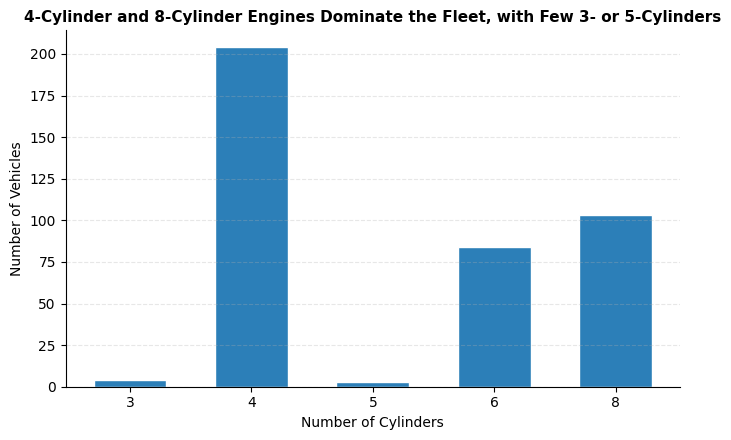

In [5]:
cyl_counts = df['cylinders'].value_counts().sort_index()

plt.figure(figsize=(7, 4.5))
plt.bar([str(c) for c in cyl_counts.index], cyl_counts.values, color='#2c7fb8', edgecolor='white', width=0.6)
plt.title("4-Cylinder and 8-Cylinder Engines Dominate the Fleet, with Few 3- or 5-Cylinders", fontsize=11, fontweight='bold')
plt.xlabel("Number of Cylinders")
plt.ylabel("Number of Vehicles")
plt.ylim(bottom=0)
plt.grid(True, axis='y', linestyle='--', alpha=0.3)
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

### Justification Q4
A **bar chart with a zero baseline** is ideal because cylinders represent discrete numeric counts where the goal is comparing absolute frequency across categories.

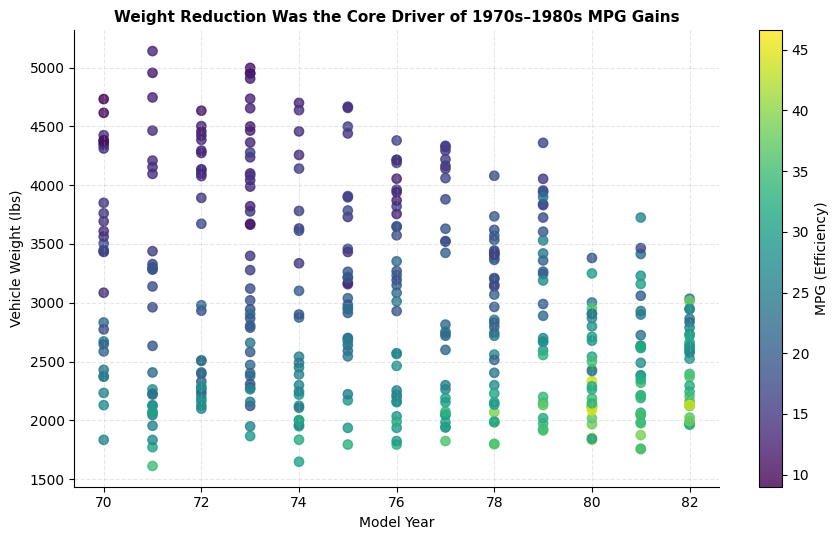

In [6]:
plt.figure(figsize=(9, 5.5))
sc = plt.scatter(df['model_year'], df['weight'], c=df['mpg'], cmap='viridis', s=45, alpha=0.8)
cbar = plt.colorbar(sc)
cbar.set_label("MPG (Efficiency)")
plt.title("Weight Reduction Was the Core Driver of 1970s–1980s MPG Gains", fontsize=11, fontweight='bold')
plt.xlabel("Model Year")
plt.ylabel("Vehicle Weight (lbs)")
plt.grid(True, linestyle='--', alpha=0.3)
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

### Justification Q5
An encoded scatter plot attempts to demonstrate that as model years advance, vehicle weight drops and MPG increases (indicated by the brighter color gradient).

**Why this chart is the weakest:**
Encoding a third continuous variable (`mpg`) into a color scale forces high cognitive effort. The eye struggles to quantitatively interpret color hues across overlapping scatter points.

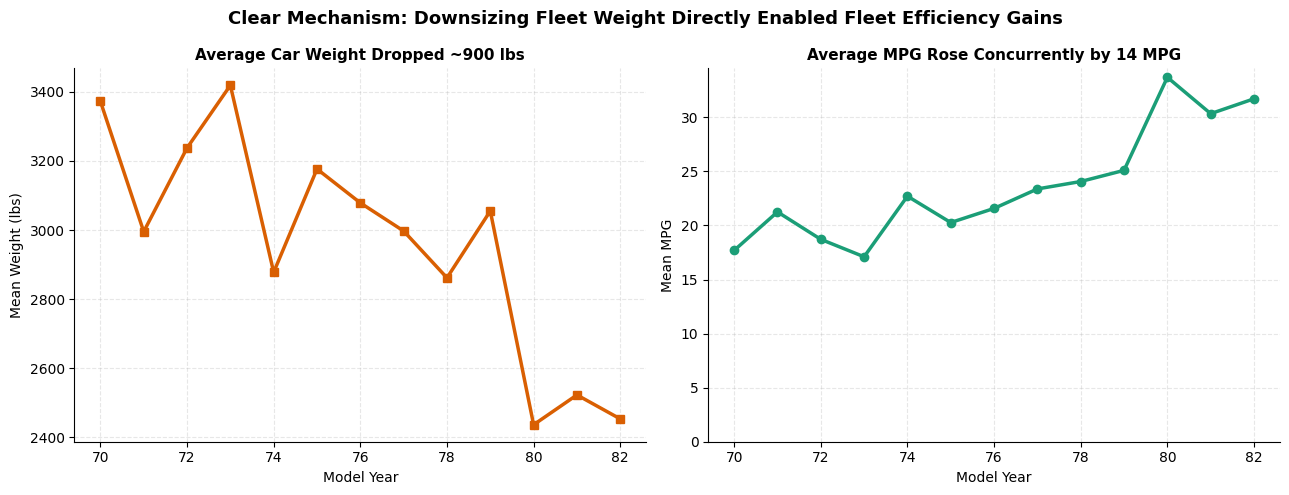

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5), sharex=True)

year_stats = df.groupby('model_year').agg(mean_weight=('weight', 'mean'), mean_mpg=('mpg', 'mean'))

ax1.plot(year_stats.index, year_stats['mean_weight'], marker='s', color='#d95f02', lw=2.5)
ax1.set_title("Average Car Weight Dropped ~900 lbs", fontsize=11, fontweight='bold')
ax1.set_ylabel("Mean Weight (lbs)")
ax1.set_xlabel("Model Year")
ax1.grid(True, linestyle='--', alpha=0.3)
ax1.spines[['top', 'right']].set_visible(False)

ax2.plot(year_stats.index, year_stats['mean_mpg'], marker='o', color='#1b9e77', lw=2.5)
ax2.set_title("Average MPG Rose Concurrently by 14 MPG", fontsize=11, fontweight='bold')
ax2.set_ylabel("Mean MPG")
ax2.set_xlabel("Model Year")
ax2.set_ylim(bottom=0)
ax2.grid(True, linestyle='--', alpha=0.3)
ax2.spines[['top', 'right']].set_visible(False)

fig.suptitle("Clear Mechanism: Downsizing Fleet Weight Directly Enabled Fleet Efficiency Gains", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Redesign Explanation
Instead of forcing a confusing colorbar encoding onto a single scatter plot, the redesign uses **two synchronized small-multiple time series side-by-side**. This obeys the "never use dual y-axes" rule while making the inverse relationship between vehicle weight and fuel efficiency immediately legible.